In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("sales_clean.csv")
df.shape

(289, 6)

### Mean, Median, and Standard Deviation

In [2]:
df[["qty", "price"]].agg(["mean", "median", "std"])

,qty,price
mean,2.979239,55.723633
median,3.000000,37.530000
std,1.409141,72.105147


#### Is median or mean the better choice to report price?
I would use the median to report the price. When looking at the mean, median and deviation, the first thing I noticed is that the deviation is much larger than the mean and the median. I also noticed mean is nearly $20 more than the median. When considering the difference with the deviation and the mean, that tells me that the price distribution is skewed to the right, meaning the mean price would be inflated. Median would be the best choice because it would be the true middle price instead of an inflated number.

### Histogram

Text(0, 0.5, '# of Sales')

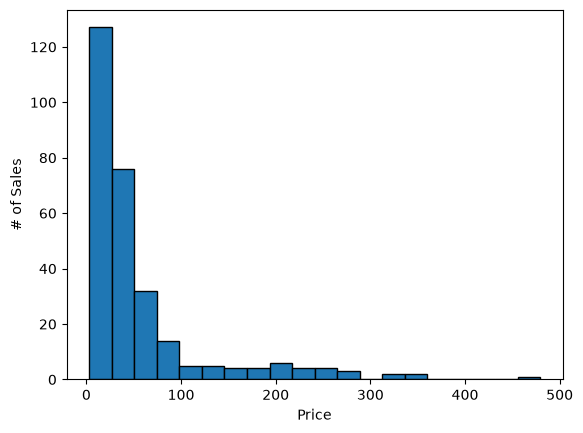

In [3]:
df["price"].plot(kind="hist", bins=20, edgecolor="black")
## labels for histogram
plt.xlabel("Price")
plt.ylabel("# of Sales")

#### Histogram Shape
This is right-skewed, it shows that most sales had prices that are low, with a tail that shows that there were a few sales of higher priced items. This proves that the mean price is inflated by the few more expensive sales.

### Creating a Revenue Column

In [4]:
df["revenue"] = df["price"]*df["qty"]
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


### Correlation Matrix

In [5]:
df.corr(numeric_only=True)

,order_id,price,qty,zip,revenue
order_id,1.000000,-0.004081,0.026030,-0.016886,0.003909
price,-0.004081,1.000000,-0.040190,0.023194,0.821184
qty,0.026030,-0.040190,1.000000,0.080835,0.313952
zip,-0.016886,0.023194,0.080835,1.000000,0.044752
revenue,0.003909,0.821184,0.313952,0.044752,1.000000


#### Strongest off-diagonal value
The strongest off diagonal value is the revenue and price. This shows that the revnue is more price driven, while quantity accounts for a relatively small amount in revenue variance.

### Scatter Plot to verify

<Axes: xlabel='qty', ylabel='revenue'>

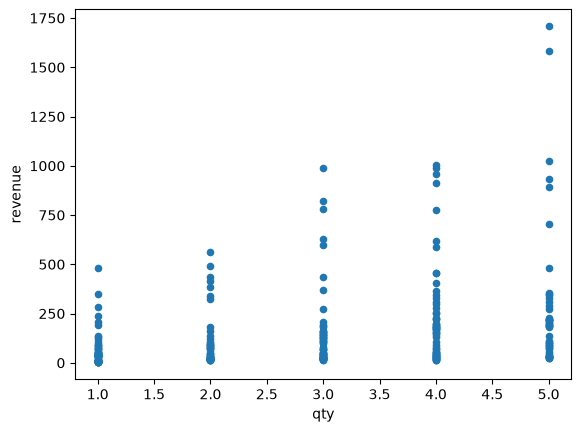

In [6]:
df.plot.scatter(x="qty", y="revenue")

#### Upward drifting cloud
With an r value of .3 we would expect to see an upward drifting cloud. Since we are looking at quantity, which were all whole numbers, we see 5 horizontal lines. When looking from left to right you can the lines start smaller on the left, and gradually get longer as you move towards the right. In other words, the lines are drifting upwards, which is exactly what we expected to see with our r value.

### Analyst's Claim
There is a strong positive relationship between price and revnue, showing that revenue is primarily driven by the item's price rather than order volume, however, this should be interperated with caution, as high value single items may disproportionally skew the observed correlation.

### Computing Mean and Median by hand
[2,4,4,6,9]  
Median = [~~2~~, 4, 4, 6, ~~9~~]  
Median = [~~2~~, ~~4~~, 4, ~~6~~, ~~9~~]  
Median = 4

Mean = (2+4+4+6+9)/5  
Mean = (25)/5  
Mean = 5

#### Verifying my math

In [7]:
x = pd.Series([2,4,4,6,9])
print (f"The Median is {x.median()}")
print(f"The Mean is {x.mean()}")

The Median is 4.0
The Mean is 5.0


#### GitHub URL
https://github.com/Alexisyarbs/cs82a-portfolio/blob/main/module4/module4_lab1.ipynb